# $F=0 \rightarrow F'=1$ MOT capture

This script shows examples about how to solve for the dynamics of a 1D MOT and
calculate things like the capture velocity.  We will deal specifically with a 1D MOT.
We can compare results to those of 1 D. Haubrich, A. Höpe, and D. Meschede, “A simple model for optical capture of atoms in strong magnetic quadrupole fields” _Optics Communications_ __102__, 225 (1993).  http://dx.doi.org/10.1016/0030-4018(93)90387-K

In this example, we will mostly focus on the heuristic force equation for an $F=0\rightarrow F'=1$ atom in a magnetic field:

$$
\mathbf{f} = \frac{\hbar \mathbf{k} \Gamma}{2}\sum_{q,i} \frac{s_i (\epsilon'_{q,i})^2}{1+\sum_js_j + 4[\Delta - \mathbf{k}_i\cdot \mathbf{v} - q \mu_B B(r)/\hbar]^2/\Gamma^2}
$$

where $\mathbf{f}$ is the force, $\Gamma$ is the decay, $q=-1,0,1$, $s_i$, $\boldsymbol{\epsilon}'_{q,i}$, and $\mathbf{k}_i$ are the intensity, polarization (rotated along the local magnetic field) and wavevector of the $i$th laser beam, respectively.  All laser parameters can can depend on time $t$ and position $\mathbf{r}$.  This equation is encoded in `pylcp.heuristiceq`.  Of course, one can also switch to the rate equations by loading `pylcp.rateeq`.

We'll use the standard 3D MOT quadrupole field,

$$
\mathbf{B} = B'\left(-\frac{1}{2}(x\hat{x} + y\hat{y})+z\hat{z}\right)
$$

where $B'$ is the magnetic field gradient.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as cts
from scipy.optimize import bisect #For root finding
import pylcp
import pylcp.atom as atom
from pylcp.common import progressBar

### Choose the units:
As with any problem in `pylcp`, the units that one chooses are arbitrary.  For this example, we are going to get fancy and use a special unit system that is only possible with the heuristic equation or, when magnetic forces are not included, the rate equations.  As in the documentation, we will denote all explicit units with a subscript and all quantities where we have removed the units with an overbar, e.g. $\bar{x} = x/x_0$.  Let's choose units where the heuristic force is given by (along the $\hat{z}$ axis):

$$
\bar{\mathbf{f}} = \frac{\hat{\mathbf{k}}}{2}\sum_{q,i}\frac{s_i (\epsilon_{q,i}')^2}{1+\sum_js_j + 4(\delta - \hat{\mathbf{k}}_i\cdot \mathbf{\bar{v}} - q \bar{z})^2}
$$

where $\delta = \Delta/\Gamma$.  This is equivalent the above equation by setting $k/\Gamma=1$ and $\mu_B B'/(\hbar \Gamma)=1$.  Or, in other words, we want a unit system that measures velocities in terms of $\Gamma/k$, positions in terms of $\hbar \Gamma/\mu_B B'$, and forces in terms of $\hbar k \Gamma$.

Programmatically, it allows us to just specify the _unit_ vector for $\mathbf{k}$ when we program `laserBeams`, set the magnetic field gradient parameter $\alpha=1$, and set $\Gamma=1$ ($\hbar=1$ by default).

So what are the length and time units of this system?  Well, the length unit is given by $x_0 = \hbar \Gamma/\mu_B B'$ and $t_0$ is defined such that

$$
\bar{v} = \frac{k v}{\Gamma}  = k \frac{x_0}{\Gamma t_0}\bar{v}
$$

implying that

$$
t_0 = \frac{k x_0}{\Gamma}
$$

Finally, we need the mass, which is defined through the prefactor to the force equation.  We'll factor out the magnitude of the $\mathbf{k}$ vector because :

$$
\ddot{\mathbf{r}} = \frac{\mathbf{f}}{m} = \frac{\hbar k \Gamma}{m}\hat{\mathbf{k}}
$$

Note that I neglected the sum, since that is dimensionless already.  I can now put in the units explicitly:

$$
\frac{x_0}{t_0^2} \ddot{\bar{\mathbf{r}}} = \frac{\hbar k \Gamma }{m}\hat{\mathbf{k}}
$$

Rearranging,

$$
\ddot{\bar{\mathbf{r}}} = \frac{\hbar k \Gamma t_0^2}{m x_0} \hat{\mathbf{k}} = \frac{\hbar k^2 t_0}{m}\hat{\mathbf{k}} = \frac{\bar{\mathbf{f}}}{\bar{m}}
$$

where $\bar{m} = m/(\hbar k^2 t_0)$.

Note again that this unit system is effectively measuring lengths in two different ways - one in terms of $k$ and the other in terms of the magnetic field.  This works because we have the mass term which we can adjust.  However, if you wanted to include magnetic forces, or use the optical Bloch equations, this unit system will not work as the forces calculated in those schemes have quite a different constant.

Plugging in the numbers, we find:

In [2]:
x0 = (6/1.4/15) # cm
k = 2*np.pi/780E-7 # cm^{-1}
kbar = k*x0

gamma = 2*np.pi*6e6
t0 = k*x0/gamma
print(x0, k, kbar, 1/gamma, t0)

mass = 86.909180527*cts.value('atomic mass constant')/(cts.hbar*(k*1e2)**2*t0)
print(mass)

0.2857142857142857 80553.65778435367 23015.33079552962 2.6525823848649224e-08 0.0006105006105006105
0.03454474236299846


### Define the problem

As always, we must define the laser beams, magnetic field and Hamiltonian.

In [3]:
det = -1.5
alpha = 1.0
s = 1.0

laserBeams = pylcp.laserBeams([
    {'kvec':np.array([0., 0., 1.]), 'pol':np.array([0., 0., 1.]), 's':s, 'delta':det},
    {'kvec':np.array([0., 0., -1.]), 'pol':np.array([1., 0., 0.]), 's':s, 'delta':det}],
    beam_type=pylcp.infinitePlaneWaveBeam
)

magField = pylcp.quadrupoleMagneticField(alpha)

# Use the heuristic equation (or comment it out):
eqn = pylcp.heuristiceq(laserBeams, magField, gamma=1, mass=mass)

# Define the atomic Hamiltonian:
# Hg, muqg = pylcp.hamiltonians.singleF(F=0, muB=1)
# He, muqe = pylcp.hamiltonians.singleF(F=1, muB=1)

# dq = pylcp.hamiltonians.dqij_two_bare_hyperfine(0, 1)

# hamiltonian = pylcp.hamiltonian(Hg, He, muqg, muqe, dq, mass=mass)

# eqn = pylcp.rateeq(laserBeams, magField, hamiltonian, include_mag_forces=False)

### Compute equilibrium force

As with the previous example, we will calculate over the 2D phase space defined by $z$ and $v_z$.

In [4]:
dz = 0.1
dv = 0.1
z = np.arange(-20, 20+dz, dz)
v = np.arange(-20, 20+dv, dv)

Z, V = np.meshgrid(z, v)

Rfull = np.array([np.zeros(Z.shape), np.zeros(Z.shape), Z])
Vfull = np.array([np.zeros(Z.shape), np.zeros(Z.shape), V])

eqn.generate_force_profile([np.zeros(Z.shape), np.zeros(Z.shape), Z],
                           [np.zeros(V.shape), np.zeros(V.shape), V],
                           name='Fz')

Plot up the result:

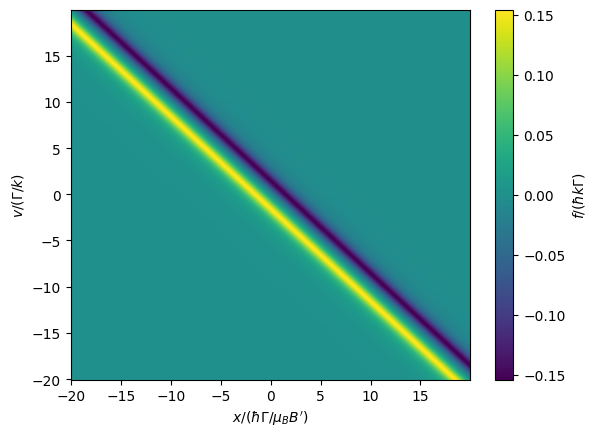

In [5]:
fig, ax = plt.subplots(1, 1)
plt.imshow(eqn.profile['Fz'].F[2], origin='lower',
           extent=(np.amin(z)-dz/2, np.amax(z)-dz/2,
                   np.amin(v)-dv/2, np.amax(v)-dv/2),
           aspect='auto')
cb1 = plt.colorbar()
cb1.set_label('$f/(\\hbar k \\Gamma)$')
ax.set_xlabel('$x/(\\hbar \\Gamma/\\mu_B B\')$')
ax.set_ylabel('$v/(\\Gamma/k)$')
fig.subplots_adjust(left=0.12,right=0.9)

### Add trajectories in phase space

We'll use the evolve motion method to evolve the particle and simulate capture.  But we also need to define some stop conditions, either when the atom is captured at the origin or lost to "$+\infty$".

In [6]:
v0s = np.arange(1, 15.5, 1)

# See solve_ivp documentation for event function discussion:
def captured_condition(t, y, threshold=1e-5):
    if(y[-4]<threshold and y[-1]<1e-3):
        val = -1.
    else:
        val = 1.
    
    return val

def lost_condition(t, y, threshold=1e-5):
    if y[-1]>20.:
        val = -1.
    else:
        val = 1.
    
    return val

captured_condition.terminal=True
lost_condition.terminal=True

sols = []
for v0 in v0s:
    eqn.set_initial_position_and_velocity(np.array([0., 0., z[0]]),
                                          np.array([0., 0., v0]))
    if isinstance(eqn, pylcp.rateeq):
        eqn.set_initial_pop(np.array([1., 0., 0., 0.]))

    eqn.evolve_motion([0., 100.], events=[captured_condition, lost_condition], max_step=0.1)
    
    sols.append(eqn.sol)

Now, plot up the additional trajectories in white:

(-20.0, 20.0)

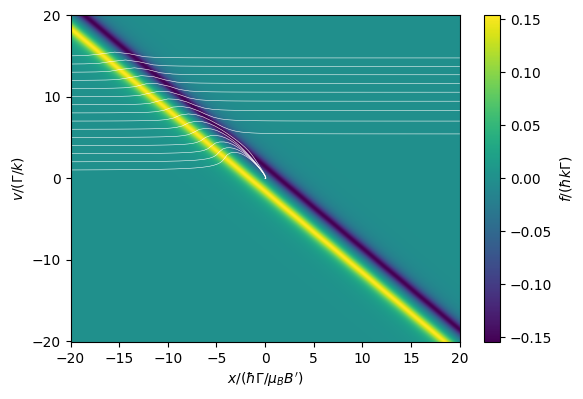

In [7]:
fig, ax = plt.subplots(1, 1)
plt.imshow(eqn.profile['Fz'].F[2], origin='lower',
           extent=(np.amin(z)-dz/2, np.amax(z)-dz/2,
                   np.amin(v)-dv/2, np.amax(v)-dv/2),
           aspect='auto')
cb1 = plt.colorbar()
cb1.set_label('$f/(\\hbar k \\Gamma)$')
ax.set_xlabel('$x/(\\hbar \\Gamma/\\mu_B B\')$')
ax.set_ylabel('$v/(\\Gamma/k)$')

fig.subplots_adjust(left=0.15, right=0.91, bottom=0.2)

for sol in sols:
    ax.plot(sol.r[2], sol.v[2], 'w-', linewidth=0.375)

ax.yaxis.set_ticks([-20, -10, 0, 10, 20])
# Display the figure at the end of the thing.
ax.set_xlim((-20, 20))
ax.set_xlim((-20, 20))

By having two conditions, we can tell if the atom was lost or captured:

In [8]:
for sol in sols:
    if len(sol.t_events[0]) == 1:
        print('captured')
    elif len(sol.t_events[1]) == 1:
        print('lost')

captured
captured
captured
captured
captured
captured
lost
lost
lost
lost
lost
lost
lost
lost
lost


### Solve for the capture velocity $v_c$

Let's define a function that figures out if we were captured or not, then use that to find the capture velocity:

In [9]:
def iscaptured(v0, z0, eqn, captured_condition, lost_condition, tmax=1000, max_step=0.1, **kwargs):
    eqn.set_initial_position_and_velocity(np.array([0., 0., z0]),
                                          np.array([0., 0., v0]))
    eqn.evolve_motion([0., tmax], events=[captured_condition, lost_condition],
                      max_step=max_step)
    
    if len(eqn.sol.t_events[0]) == 1:
        return +1.
    else:
        return -1.
    
iscaptured(1.3, z[0], eqn, captured_condition, lost_condition)

1.0

Use `scipy.optimize.bisect` to see where the `iscaptured` function changes from `-1` (false) to `1` (true):

In [10]:
bisect(iscaptured, 1.0, 15.,
       args=(z[0], eqn, captured_condition, lost_condition),
       xtol=1e-4, rtol=1e-4, full_output=True
      )

(6.20770263671875,
       converged: True
            flag: converged
  function_calls: 17
      iterations: 15
            root: 6.20770263671875
          method: bisect)

### Dependence of $v_c$ on detuning and intensity

We will figure out how the capture velocity depends on and compare to this equation from the paper in the introduction:

$$
v_c = \left(\frac{a_0^2s^2\kappa}{(1+s)^{3/2}}\right)^{1/3}\left(\frac{8\pi\delta^2}{1+s+4\delta^2}\right)^{1/3}\zeta^{-2/3}
$$

where $a_0 = \hbar k \Gamma/(2 m)$, $\zeta = \mu_B B'/(\hbar\Gamma)$, and $\kappa = 2\pi/(\lambda \Gamma)=k/\Gamma$ .  To compare, we need to express it in a way which connects with our formulae above.  The first thing to note is that $\zeta = 1/x_0$.  We also need to multiple both sides by $k/\Gamma$, so that we have $v_c/(\Gamma/k)$ on the left side, which is our observable.  Then, we realize that

$$
\frac{\hbar k\Gamma}{2m} = \frac{1}{2\bar{m}}\frac{x_0}{t_0^2}~~~~~\text{and}~~~~~\frac{k}{\Gamma} = \frac{t_0}{x_0} 
$$

Putting it all together:

$$
\frac{v_c}{\Gamma/k} = \frac{t_0}{x_0}\left(\frac{1}{2\bar{m}}\right)^{2/3} \frac{x_0^{2/3}}{t_0^{4/3}}\frac{t_0^{1/3}}{x_0^{1/3}} x_0^{2/3}\left(\frac{s^2}{(1+s)^{3/2}}\right)^{1/3}\left(\frac{8\pi\delta^2}{1+s+4\delta^2}\right)^{1/3} = \left(\frac{1}{2\bar{m}}\right)^{2/3}\left(\frac{s^2}{(1+s)^{3/2}}\right)^{1/3}\left(\frac{8\pi\delta^2}{1+s+4\delta^2}\right)^{1/3}
$$

In [11]:
dets = -np.logspace(-1, np.log10(5), 30)[::-1]
intensities = np.array([0.3, 1., 3.])

DETS, INTENSITIES = np.meshgrid(dets, intensities)

it = np.nditer([DETS, INTENSITIES, None, None],
               op_dtypes=['float64', 'float64', 'float64', object])

progress = progressBar()
for (det, s, vc, full_results) in it:
    laserBeams = pylcp.laserBeams([
        {'kvec':np.array([0., 0., 1.]), 'pol':np.array([0., 0., 1.]), 's':s, 'delta':det},
        {'kvec':np.array([0., 0., -1.]), 'pol':np.array([1., 0., 0.]), 's':s, 'delta':det}],
        beam_type=pylcp.infinitePlaneWaveBeam
    )

    # Heuristic equation or rate equation?
    eqn = pylcp.heuristiceq(laserBeams, magField, gamma=1, mass=mass)
    #eqn = pylcp.rateeq(laserBeams, magField, hamiltonian, include_mag_forces=False)
    
    if isinstance(eqn, pylcp.rateeq):
        eqn.set_initial_pop(np.array([1., 0., 0., 0.]))
        
    vc[...], full_results[...] = bisect(
        iscaptured, 0.5, 15.0,
        args=(z[0], eqn, captured_condition, lost_condition),
        rtol=1e-4, xtol=1e-4, full_output=True
    )

    progress.update((it.iterindex+1)/it.itersize)

Completed in 19:51.                                                 


In [12]:
def vc_from_paper(delta, s, mbar):
    return 1/(2*mbar)**(2./3.)*(s**2/(1+s)**(3./2.))**(1./3.)*(8*np.pi*delta**2/(1+s+4*delta**2))**(1./3.)

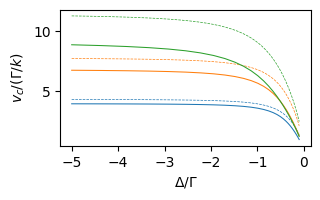

In [13]:
dets_thr = -np.logspace(-1, np.log10(5), 51)[::-1]
fig, ax = plt.subplots(1, 1, figsize=(3.25, 2))
for ii, (s, vc_vs_det) in enumerate(zip(intensities, it.operands[2])):
    ax.plot(dets, vc_vs_det, label='$s=%.1f$' % s,
            color='C%d'%ii, linewidth=0.75)
    ax.plot(dets_thr, vc_from_paper(dets_thr, s, mass), '--',
            color='C%d'%ii, linewidth=0.5)

#ax.legend(fontsize=8)
ax.set_xlabel('$\\Delta/\\Gamma$')
ax.set_ylabel('$v_c/(\\Gamma/k)$')

fig.subplots_adjust(left=0.13, bottom=0.2)